# Weather Features

**Purpose:** Fetch hourly weather data for London from the Open-Meteo API, merge it
into `quotes_hourly_h3.parquet`, and visualise the relationship between weather
conditions and quote volume. Also fetches the Apr 1–7 forecast for future prediction.

**Outputs:**
- `data/processed/quotes_weather_h3.parquet` — quotes + March weather (training data)
- `data/processed/weather_forecast_apr2026.parquet` — Apr 1–7 forecast (prediction input)

**What is important for you in this notebook**

- I fetch hourly data for:
  - "temperature_2m" – Air temperature measured 2 meters above ground (°C)
  - "apparent_temperature" – Feels-like temperature accounting for wind and humidity (°C)
  - "rain" – Rainfall amount from liquid precipitation (mm)
  - "precipitation" – Total precipitation including rain, snow, etc. (mm)
  - "precipitation_probability" – Likelihood of precipitation occurring (%)
  - "wind_speed_10m" – Wind speed measured 10 meters above ground (km/h or m/s)
  - "cloud_cover" – Fraction of sky covered by clouds (%)
  - "visibility" – Horizontal visibility distance (meters or km)
- For all analysis, but point #8 I use cumulative number of quotes created within all hexagones selected for predictions. 
- Pay attention to point #7 Weather vs. demand visualisations
  - 7a-b. Top-4 predictiors of total number of quotes for cumulative number of quotes created within selected hexagones are: temperature_2m, apparent_temperature, precipation and visibility. Intrestingly, that temperature_2m has corr=0.22, while apparent_temperatue has corr=0.14.
  - 7c. Rainy hours produce noticeably more quotes on average than dry hours (verified by t-test), the dry group's mean is 3.09 standard errors below the rainy group's mean.
  - 7d. Quote volume generally increases from coldest to warmest — Q1 (coldest) has the lowest median (~450) while Q4 (warmest) has the highest (~700).
  - 7e. Quote volume rises with wind speed, but the trend loses reliability beyond Breezy given the small samples in Windy (n=61) and especially Strong (n=6).
- Point #8 does not give a lot of insight, the main conclusion is that weather conditions affect number of quotes generated differenltly depending on a geographic zone.

**Contents**

1. Fetch March 2026 historical weather
2. Fetch April 1–7 2026 forecast and save
3. Load quotes parquet
4. Merge March weather onto quotes
5. Describe merged table and check coverage
6. Weather time-series overview
7. Weather vs. demand visualisations
8. Per-zone correlation choropleth maps
9. Save merged output

In [17]:
import sys
sys.path.insert(0, "..")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from scipy import stats
import openmeteo_requests
import requests_cache
from retry_requests import retry

DATA_DIR      = Path("../data")
IN_PATH       = DATA_DIR / "processed" / "quotes_hourly_h3.parquet"
OUT_PATH      = DATA_DIR / "processed" / "quotes_weather_h3.parquet"
FORECAST_PATH = DATA_DIR / "processed" / "weather_forecast_apr2026.parquet"

WEATHER_VARS = [
    "temperature_2m",
    "apparent_temperature",
    "rain",
    "precipitation",
    "precipitation_probability",
    "wind_speed_10m",
    "cloud_cover",
    "visibility",
]

UNITS = {
    "temperature_2m":            "°C",
    "apparent_temperature":      "°C",
    "rain":                      "mm",
    "precipitation":             "mm",
    "precipitation_probability": "%",
    "wind_speed_10m":            "km/h",
    "cloud_cover":               "%",
    "visibility":                "m",
}

## 1. Fetch March 2026 historical weather

In [18]:
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo     = openmeteo_requests.Client(session=retry_session)

BASE_PARAMS = {
    "latitude":  51.5085,
    "longitude": -0.1257,
    "hourly":    WEATHER_VARS,
    "timezone":  "UTC",
}

def fetch_weather(start_date: str, end_date: str) -> pd.DataFrame:
    """Fetch hourly weather from Open-Meteo and return a tidy DataFrame."""
    params    = {**BASE_PARAMS, "start_date": start_date, "end_date": end_date}
    response  = openmeteo.weather_api("https://api.open-meteo.com/v1/forecast", params=params)[0]
    hourly    = response.Hourly()
    df = pd.DataFrame({
        "hour_bucket": pd.date_range(
            start     = pd.to_datetime(hourly.Time(),    unit="s", utc=True),
            end       = pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq      = pd.Timedelta(seconds=hourly.Interval()),
            inclusive = "left",
        ),
        **{var: hourly.Variables(i).ValuesAsNumpy() for i, var in enumerate(WEATHER_VARS)},
    })
    return df

weather_march = fetch_weather("2026-03-01", "2026-03-31")
print(f"March weather rows : {len(weather_march):,}")
print(f"Range : {weather_march['hour_bucket'].min()}  →  {weather_march['hour_bucket'].max()}")
weather_march.head()

March weather rows : 744
Range : 2026-03-01 00:00:00+00:00  →  2026-03-31 23:00:00+00:00


,hour_bucket,temperature_2m,apparent_temperature,rain,precipitation,precipitation_probability,wind_speed_10m,cloud_cover,visibility
0,2026-03-01 00:00:00+00:00,7.8955,5.146195,0.0,0.0,20.0,9.000000,95.0,25860.0
1,2026-03-01 01:00:00+00:00,7.9955,4.904705,0.0,0.0,23.0,12.240000,100.0,26900.0
2,2026-03-01 02:00:00+00:00,8.0455,4.754730,0.0,0.0,25.0,13.679999,100.0,28680.0
3,2026-03-01 03:00:00+00:00,8.1455,4.807522,0.0,0.0,24.0,14.400000,86.0,28240.0
4,2026-03-01 04:00:00+00:00,8.1455,5.122522,0.0,0.0,19.0,12.240000,100.0,23540.0


## 2. Fetch April 1–7 2026 forecast and save

Saved separately as the prediction-time covariate input — no quotes to merge
against yet.

In [19]:
weather_apr = fetch_weather("2026-04-01", "2026-04-07")
print(f"April forecast rows : {len(weather_apr):,}")
print(f"Range : {weather_apr['hour_bucket'].min()}  →  {weather_apr['hour_bucket'].max()}")

weather_apr.to_parquet(FORECAST_PATH, index=False)
print(f"\nSaved → {FORECAST_PATH}")
weather_apr.head()

April forecast rows : 168
Range : 2026-04-01 00:00:00+00:00  →  2026-04-07 23:00:00+00:00

Saved → ../data/processed/weather_forecast_apr2026.parquet


,hour_bucket,temperature_2m,apparent_temperature,rain,precipitation,precipitation_probability,wind_speed_10m,cloud_cover,visibility
0,2026-04-01 00:00:00+00:00,12.145500,10.695488,0.0,0.0,0.0,5.76,0.0,13780.0
1,2026-04-01 01:00:00+00:00,11.845500,10.122841,0.0,0.0,0.0,6.48,59.0,16100.0
2,2026-04-01 02:00:00+00:00,11.195499,9.761518,0.0,0.0,0.0,5.40,65.0,13880.0
3,2026-04-01 03:00:00+00:00,11.195499,9.721622,0.0,0.0,0.0,5.04,86.0,14560.0
4,2026-04-01 04:00:00+00:00,10.945499,9.134180,0.0,0.0,1.0,5.40,25.0,15200.0


## 3. Load quotes parquet

In [20]:
quotes = pd.read_parquet(IN_PATH)
print(f"Quotes rows : {len(quotes):,}  |  Zones : {quotes['h3_zone'].nunique()}")
print(f"Range : {quotes['hour_bucket'].min()}  →  {quotes['hour_bucket'].max()}")
quotes.head()

Quotes rows : 25,214  |  Zones : 35
Range : 2026-03-01 00:00:00+00:00  →  2026-03-31 23:00:00+00:00


,h3_zone,hour_bucket,quote_count,trip_count,conversion_rate,hour_of_day,day_of_week,cv_risk
0,87194ad06ffffff,2026-03-01 00:00:00+00:00,12,6,0.500000,0,6,cv_50
1,87194ad06ffffff,2026-03-01 01:00:00+00:00,16,2,0.125000,1,6,cv_50
2,87194ad06ffffff,2026-03-01 02:00:00+00:00,18,4,0.222222,2,6,cv_50
3,87194ad06ffffff,2026-03-01 03:00:00+00:00,19,6,0.315789,3,6,cv_50
4,87194ad06ffffff,2026-03-01 04:00:00+00:00,5,2,0.400000,4,6,cv_50


## 4. Merge March weather onto quotes

Weather is the same for every zone within a given hour — one weather row
broadcasts across all zones via a left join on `hour_bucket`.

In [21]:
weather_march["hour_bucket"] = weather_march["hour_bucket"].dt.tz_convert("UTC")
quotes["hour_bucket"]        = quotes["hour_bucket"].dt.tz_convert("UTC")

merged = quotes.merge(weather_march, on="hour_bucket", how="left")

print(f"Merged shape : {merged.shape}")
merged.head()

Merged shape : (25214, 16)


,h3_zone,hour_bucket,quote_count,trip_count,conversion_rate,hour_of_day,day_of_week,cv_risk,temperature_2m,apparent_temperature,rain,precipitation,precipitation_probability,wind_speed_10m,cloud_cover,visibility
0,87194ad06ffffff,2026-03-01 00:00:00+00:00,12,6,0.500000,0,6,cv_50,7.8955,5.146195,0.0,0.0,20.0,9.000000,95.0,25860.0
1,87194ad06ffffff,2026-03-01 01:00:00+00:00,16,2,0.125000,1,6,cv_50,7.9955,4.904705,0.0,0.0,23.0,12.240000,100.0,26900.0
2,87194ad06ffffff,2026-03-01 02:00:00+00:00,18,4,0.222222,2,6,cv_50,8.0455,4.754730,0.0,0.0,25.0,13.679999,100.0,28680.0
3,87194ad06ffffff,2026-03-01 03:00:00+00:00,19,6,0.315789,3,6,cv_50,8.1455,4.807522,0.0,0.0,24.0,14.400000,86.0,28240.0
4,87194ad06ffffff,2026-03-01 04:00:00+00:00,5,2,0.400000,4,6,cv_50,8.1455,5.122522,0.0,0.0,19.0,12.240000,100.0,23540.0


## 5. Describe merged table and check coverage

In [22]:
print("Missing values per weather column:")
print(merged[WEATHER_VARS].isna().sum())
print()
merged[WEATHER_VARS].describe().round(2)

Missing values per weather column:
temperature_2m               0
apparent_temperature         0
rain                         0
precipitation                0
precipitation_probability    0
wind_speed_10m               0
cloud_cover                  0
visibility                   0
dtype: int64



,temperature_2m,apparent_temperature,rain,precipitation,precipitation_probability,wind_speed_10m,cloud_cover,visibility
count,25214.00,25214.00,25214.00,25214.00,25214.00,25214.00,25214.00,25214.00
mean,9.71,6.62,0.03,0.03,10.03,12.02,66.83,15616.20
std,2.95,3.23,0.18,0.18,22.97,5.86,41.81,7993.29
min,2.30,-1.01,0.00,0.00,0.00,0.36,0.00,1460.00
25%,7.80,4.62,0.00,0.00,0.00,7.92,17.00,8620.00
50%,9.50,6.57,0.00,0.00,0.00,10.80,97.00,16560.00
75%,11.45,8.36,0.00,0.00,5.00,15.48,100.00,21520.00
max,18.85,15.88,2.90,2.90,100.00,32.76,100.00,37340.00


## 6. Weather time-series overview

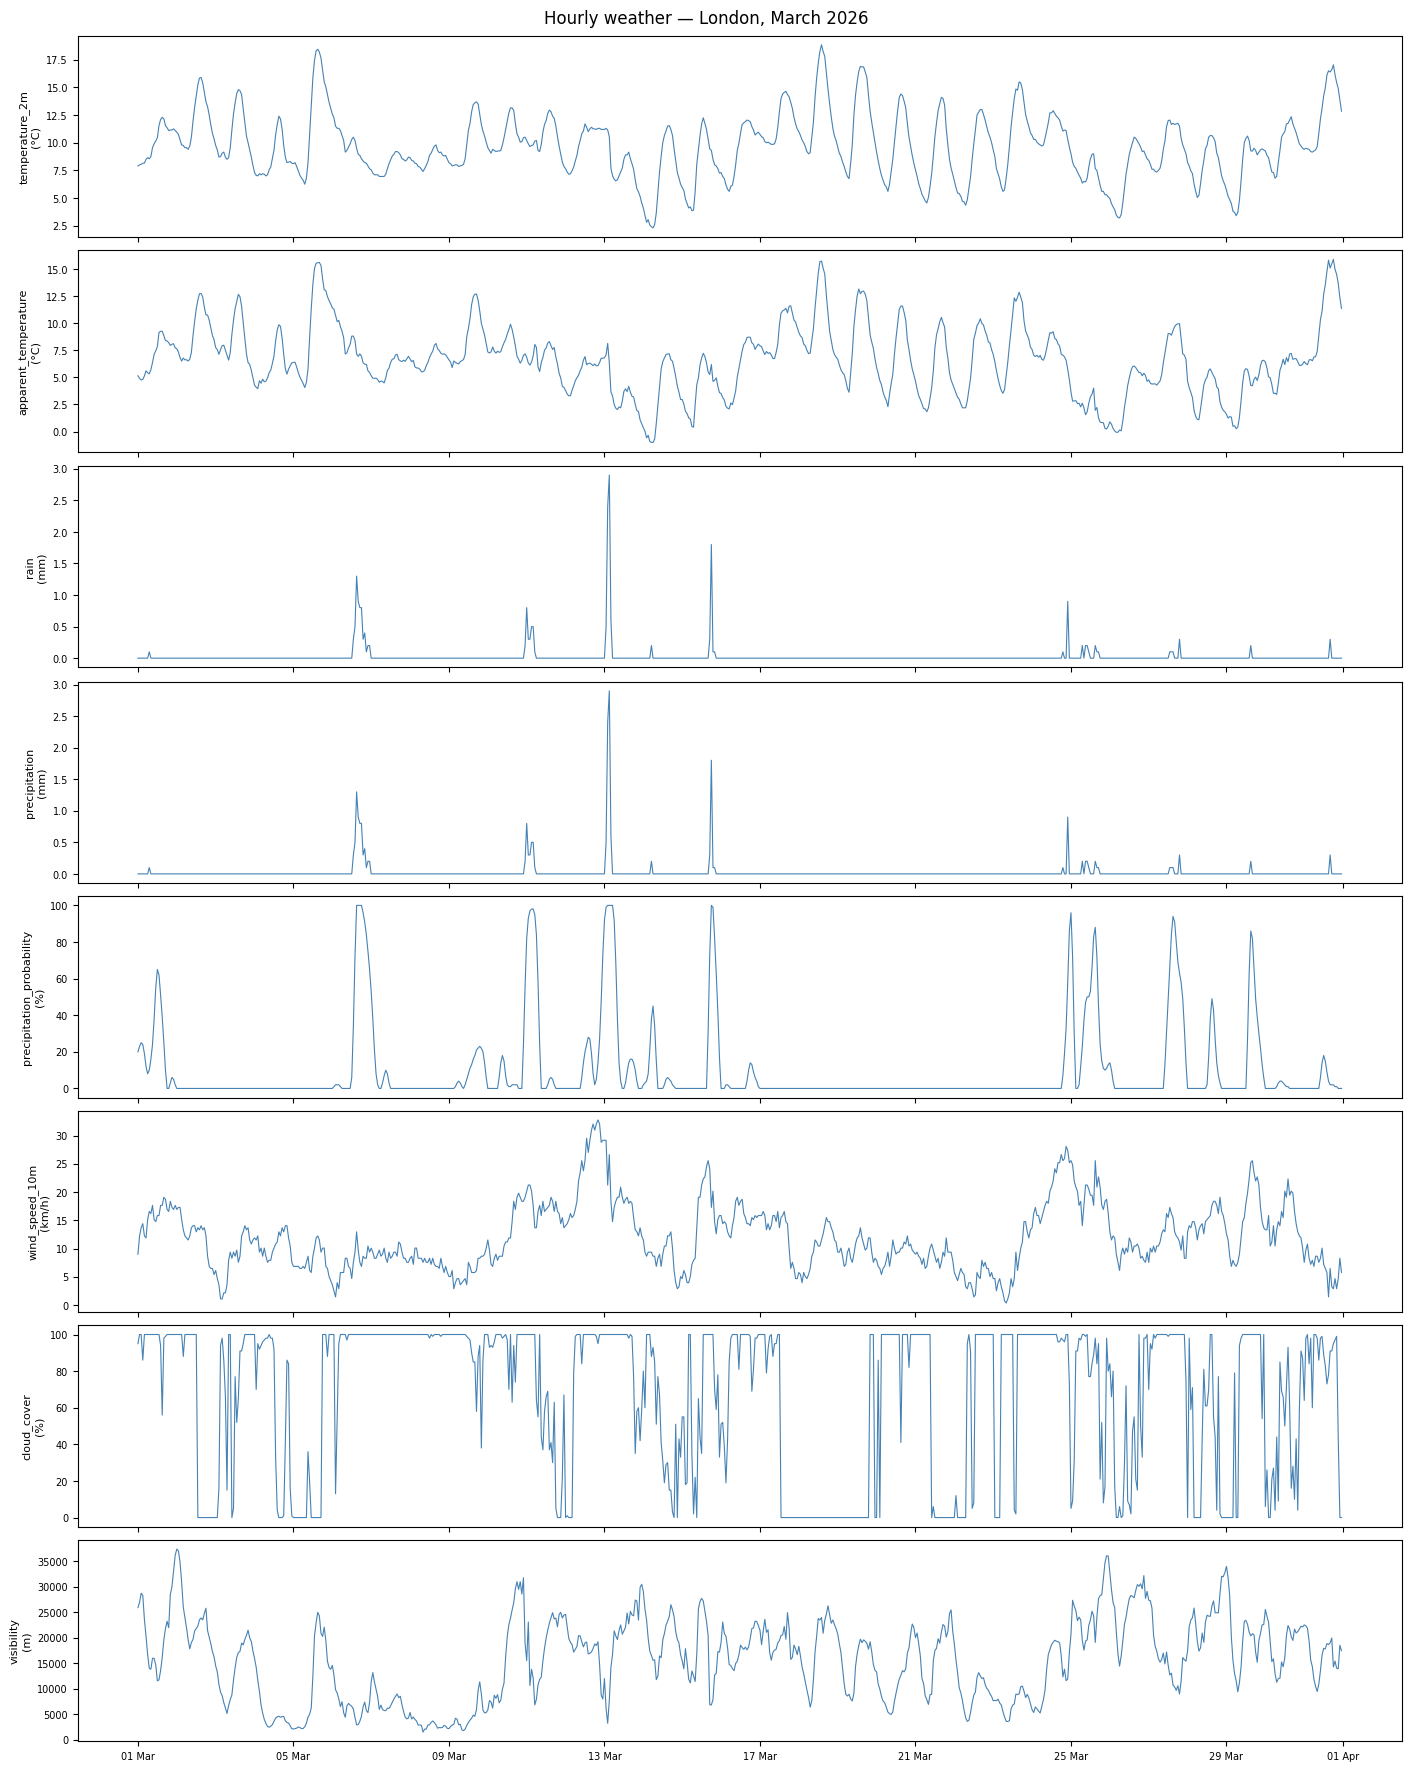

In [23]:
ts = merged.groupby("hour_bucket", sort=True)[WEATHER_VARS].first()

fig, axes = plt.subplots(len(WEATHER_VARS), 1,
                          figsize=(14, 2.2 * len(WEATHER_VARS)),
                          sharex=True, constrained_layout=True)

for ax, col in zip(axes, WEATHER_VARS):
    ax.plot(ts.index, ts[col], linewidth=0.8, color="steelblue")
    ax.set_ylabel(f"{col}\n({UNITS[col]})", fontsize=8)
    ax.tick_params(labelsize=7)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
fig.suptitle("Hourly weather — London, March 2026", fontsize=12)
plt.show()

## 7. Weather vs. demand visualisations

All analyses below use **total quotes per hour** (summed across all zones) as the
demand signal, joined to the single weather reading for that hour.

### 7a. Correlation bar chart — which variables move with quote volume?

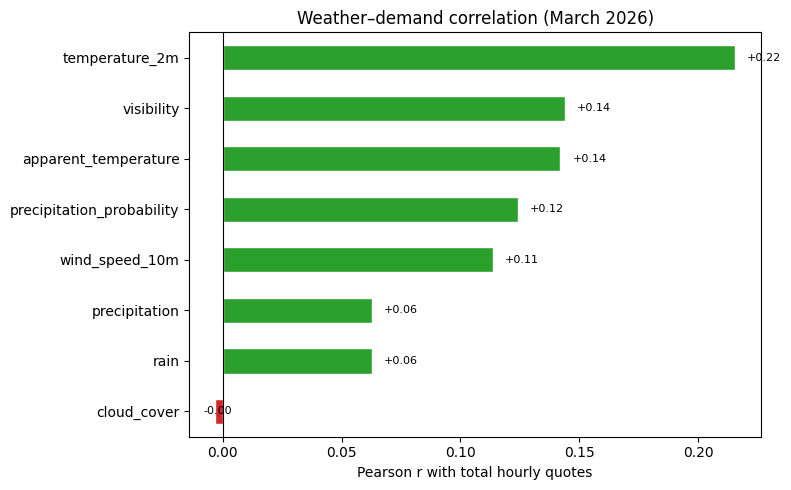

cloud_cover                 -0.003
rain                         0.063
precipitation                0.063
wind_speed_10m               0.114
precipitation_probability    0.124
apparent_temperature         0.142
visibility                   0.144
temperature_2m               0.216


In [24]:
# Hourly totals: one row per hour
hourly_demand = (
    merged.groupby("hour_bucket", sort=True)
    .agg(total_quotes=("quote_count", "sum"), **{v: (v, "first") for v in WEATHER_VARS})
    .reset_index()
)

corrs = (
    hourly_demand[WEATHER_VARS]
    .corrwith(hourly_demand["total_quotes"])
    .sort_values()
)

colors = ["#d62728" if c < 0 else "#2ca02c" for c in corrs]

fig, ax = plt.subplots(figsize=(8, 5))
corrs.plot.barh(ax=ax, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson r with total hourly quotes")
ax.set_title("Weather–demand correlation (March 2026)")
for bar, val in zip(ax.patches, corrs):
    ax.text(val + 0.005 * np.sign(val), bar.get_y() + bar.get_height() / 2,
            f"{val:+.2f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()
print(corrs.round(3).to_string())

### 7b. Scatter + regression — top 4 most correlated variables

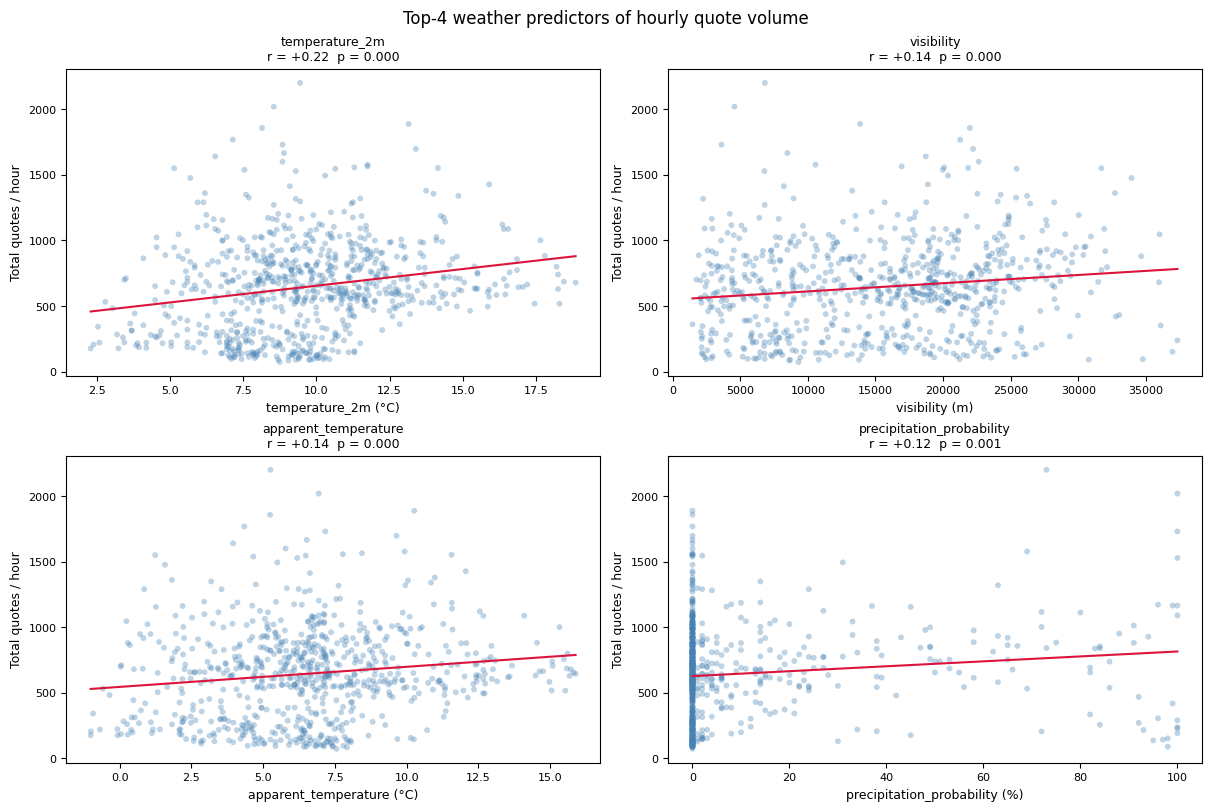

In [25]:
top4 = corrs.abs().nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for ax, col in zip(axes.flat, top4):
    x = hourly_demand[col].values
    y = hourly_demand["total_quotes"].values
    mask = np.isfinite(x) & np.isfinite(y)
    slope, intercept, r, p, _ = stats.linregress(x[mask], y[mask])
    x_line = np.linspace(x[mask].min(), x[mask].max(), 100)

    ax.scatter(x, y, alpha=0.35, s=18, color="steelblue", edgecolors="none")
    ax.plot(x_line, slope * x_line + intercept, color="crimson", linewidth=1.5)
    ax.set_xlabel(f"{col} ({UNITS[col]})", fontsize=9)
    ax.set_ylabel("Total quotes / hour", fontsize=9)
    ax.set_title(f"{col}\nr = {r:+.2f}  p = {p:.3f}", fontsize=9)
    ax.tick_params(labelsize=8)

fig.suptitle("Top-4 weather predictors of hourly quote volume", fontsize=12)
plt.show()

### 7c. Rain vs. dry — box plot of hourly quote volume

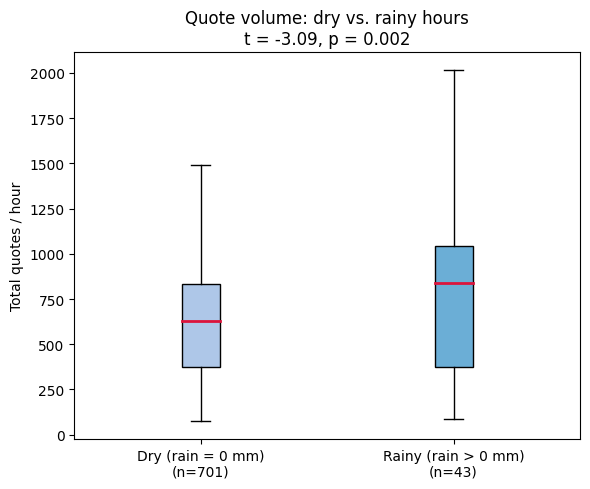

In [26]:
hourly_demand["rain_label"] = np.where(
    hourly_demand["rain"] > 0, "Rainy (rain > 0 mm)", "Dry (rain = 0 mm)"
)

groups   = [hourly_demand.loc[hourly_demand["rain_label"] == lbl, "total_quotes"].values
            for lbl in ["Dry (rain = 0 mm)", "Rainy (rain > 0 mm)"]]
labels   = ["Dry (rain = 0 mm)", "Rainy (rain > 0 mm)"]
n_counts = [len(g) for g in groups]

fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot(groups, labels=[f"{l}\n(n={n})" for l, n in zip(labels, n_counts)],
               showfliers=False, patch_artist=True,
               medianprops={"color": "crimson", "linewidth": 2})
colors_box = ["#aec7e8", "#6baed6"]
for patch, c in zip(bp["boxes"], colors_box):
    patch.set_facecolor(c)

# t-test
t_stat, p_val = stats.ttest_ind(*groups)
ax.set_ylabel("Total quotes / hour")
ax.set_title(f"Quote volume: dry vs. rainy hours\nt = {t_stat:.2f}, p = {p_val:.3f}")
plt.tight_layout()
plt.show()

### 7d. Temperature quartile bins vs. quote volume

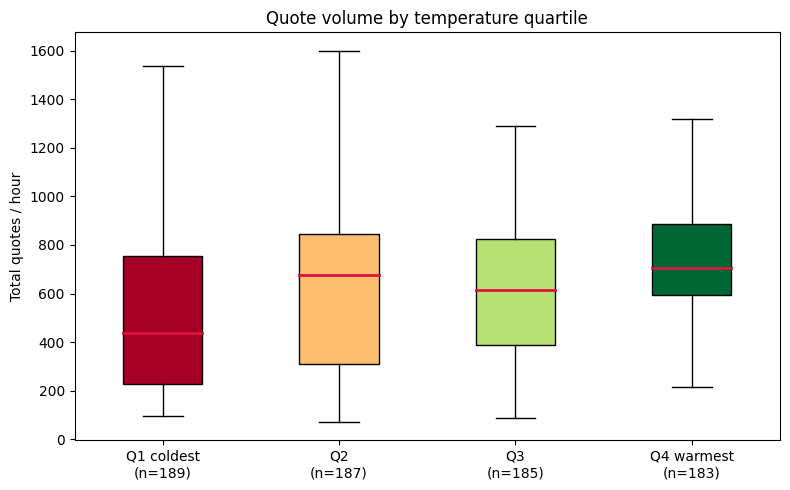

In [27]:
hourly_demand["temp_bin"] = pd.qcut(
    hourly_demand["temperature_2m"], q=4,
    labels=["Q1 coldest", "Q2", "Q3", "Q4 warmest"]
)

bin_groups = [hourly_demand.loc[hourly_demand["temp_bin"] == b, "total_quotes"].values
              for b in ["Q1 coldest", "Q2", "Q3", "Q4 warmest"]]
bin_labels = [f"{b}\n(n={len(g)})" for b, g in
              zip(["Q1 coldest", "Q2", "Q3", "Q4 warmest"], bin_groups)]

fig, ax = plt.subplots(figsize=(8, 5))
bp2 = ax.boxplot(bin_groups, labels=bin_labels, showfliers=False, patch_artist=True,
                 medianprops={"color": "crimson", "linewidth": 2})
cmap = plt.cm.RdYlGn
for i, patch in enumerate(bp2["boxes"]):
    patch.set_facecolor(cmap(i / 3))

ax.set_ylabel("Total quotes / hour")
ax.set_title("Quote volume by temperature quartile")
plt.tight_layout()
plt.show()

### 7e. Wind speed bins vs. quote volume

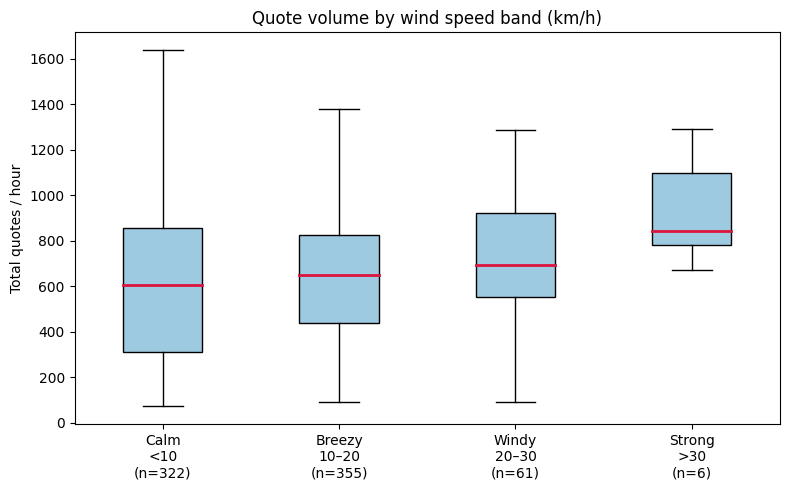

In [30]:
hourly_demand["wind_bin"] = pd.cut(
    hourly_demand["wind_speed_10m"],
    bins=[0, 10, 20, 30, 100],
    labels=["Calm\n<10", "Breezy\n10–20", "Windy\n20–30", "Strong\n>30"],
    right=True,
)

wind_groups = [
    hourly_demand.loc[hourly_demand["wind_bin"] == b, "total_quotes"].values
    for b in ["Calm\n<10", "Breezy\n10–20", "Windy\n20–30", "Strong\n>30"]
]
wind_labels = [
    f"{b}\n(n={len(g)})" for b, g in
    zip(["Calm\n<10", "Breezy\n10–20", "Windy\n20–30", "Strong\n>30"], wind_groups)
]

fig, ax = plt.subplots(figsize=(8, 5))
bp3 = ax.boxplot([g for g in wind_groups if len(g) > 0],
                 labels=[l for l, g in zip(wind_labels, wind_groups) if len(g) > 0],
                 showfliers=False, patch_artist=True,
                 medianprops={"color": "crimson", "linewidth": 2})
for patch in bp3["boxes"]:
    patch.set_facecolor("#9ecae1")

ax.set_ylabel("Total quotes / hour")
ax.set_title("Quote volume by wind speed band (km/h)")
plt.tight_layout()
plt.show()

### 8. Per-zone correlation maps

For each weather variable, each hexagon is coloured by the Pearson r between
its own hourly `quote_count` and that variable's hourly value.
Diverging colormap centred at 0: blue = negative correlation, red = positive.

In [31]:
import h3
import geopandas as gpd
from shapely.geometry import Polygon
from math import ceil

# ── Per-zone Pearson r for each weather variable ───────────────────────────
zone_corr_rows = []
for zone, zdf in merged.groupby("h3_zone"):
    row = {"h3_zone": zone}
    for var in WEATHER_VARS:
        row[var] = zdf["quote_count"].corr(zdf[var])
    zone_corr_rows.append(row)

zone_corr_df = pd.DataFrame(zone_corr_rows)
print(f"Zone correlation table: {zone_corr_df.shape}")
zone_corr_df.head()


Zone correlation table: (35, 9)


,h3_zone,temperature_2m,apparent_temperature,rain,precipitation,precipitation_probability,wind_speed_10m,cloud_cover,visibility
0,87194ad06ffffff,-0.064565,-0.074269,0.014552,0.014552,0.032252,-0.048020,0.025867,0.082160
1,87194ad10ffffff,0.029117,-0.007685,0.060268,0.060268,0.104976,0.015993,-0.007261,0.064278
2,87194ad12ffffff,0.157741,0.117815,0.090409,0.090409,0.123950,0.065963,0.010607,0.027051
3,87194ad13ffffff,0.002642,-0.030687,0.106480,0.106480,0.106343,0.048458,-0.004990,0.040935
4,87194ad14ffffff,0.233184,0.162993,0.055835,0.055835,0.045956,0.113950,-0.000567,0.085007


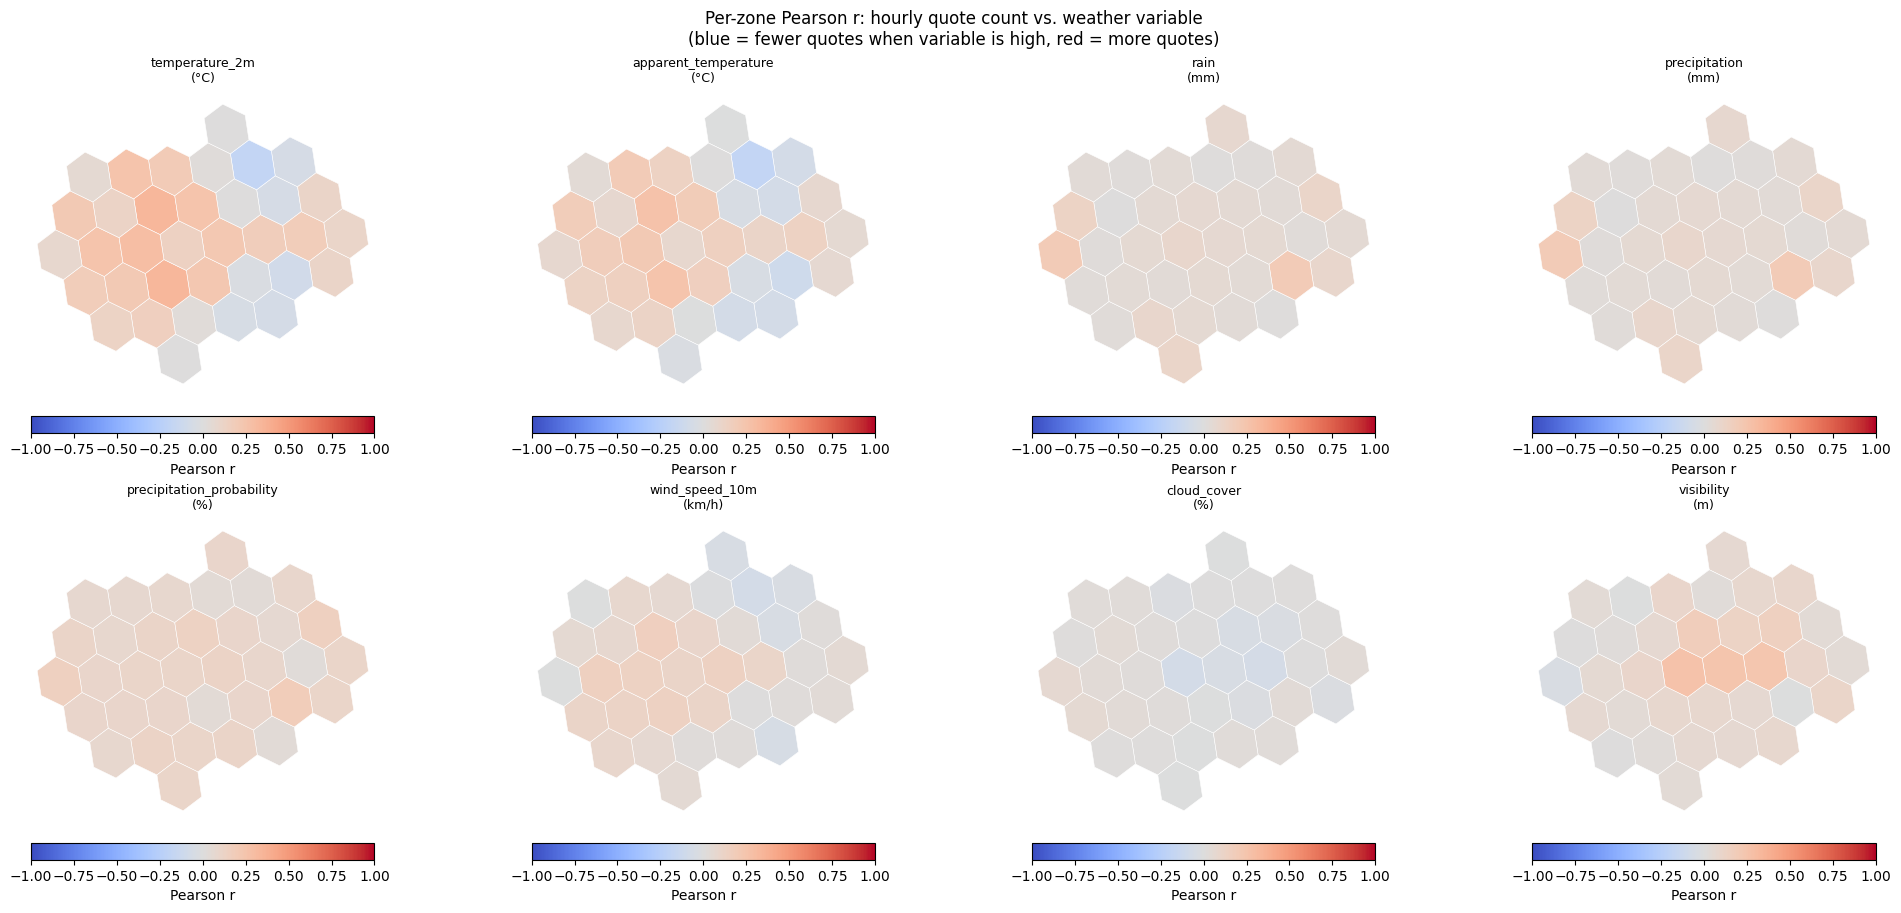

In [32]:
# ── Build H3 hexagon GeoDataFrame ──────────────────────────────────────────
def h3_to_polygon(cell):
    coords = h3.cell_to_boundary(cell)
    return Polygon([(lon, lat) for lat, lon in coords])

zones_gdf = gpd.GeoDataFrame(
    zone_corr_df,
    geometry=[h3_to_polygon(z) for z in zone_corr_df["h3_zone"]],
    crs="EPSG:4326",
)

# ── One choropleth map per weather variable ─────────────────────────────────
NCOLS   = 4
n_vars  = len(WEATHER_VARS)
nrows   = ceil(n_vars / NCOLS)

fig, axes = plt.subplots(
    nrows, NCOLS,
    figsize=(NCOLS * 5, nrows * 4.5),
    constrained_layout=True,
)
axes_flat = axes.flatten() if nrows > 1 else axes

for ax, var in zip(axes_flat, WEATHER_VARS):
    zones_gdf.plot(
        column=var,
        cmap="coolwarm",
        vmin=-1, vmax=1,
        legend=True,
        legend_kwds={
            "label": f"Pearson r",
            "shrink": 0.7,
            "orientation": "horizontal",
        },
        ax=ax,
        edgecolor="white",
        linewidth=0.4,
    )
    ax.set_title(
        f"{var}\n({UNITS[var]})",
        fontsize=9,
    )
    ax.set_axis_off()

# Hide unused axes
for ax in axes_flat[n_vars:]:
    ax.set_visible(False)

fig.suptitle(
    "Per-zone Pearson r: hourly quote count vs. weather variable\n"
    "(blue = fewer quotes when variable is high, red = more quotes)",
    fontsize=12,
)
plt.show()


## 9. Save merged output

In [ ]:
merged.to_parquet(OUT_PATH, index=False)
